# Formative Assignment: Advanced Linear Algebra (PCA)
**Group / Peer Pair:** [Peer_Pair_Number] | **Members:** Gatete Derrick, [Name 2]
**GitHub repo:** https://github.com/Abdull-Kudus/pca-rwanda-food-prices.git

This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .
1. Make sure to display outputs for each code cell when submitting.
2. Do not write all your code on one cell
3. Do not use any libraries aside from numpy (matplotlib is used only for plots)

### Dataset: Rwanda food prices (WFP / HDX)
**File:** `wfp_food_prices_rwa.csv`, downloaded unchanged from the World Food Programme's Rwanda - Food Prices dataset on the Humanitarian Data Exchange (HDX): [https://data.humdata.org/dataset/wfp-food-prices-for-rwanda](https://data.humdata.org/dataset/wfp-food-prices-for-rwanda)

**Why it matters:** food makes up a large share of household spending in Rwanda, so these prices show food security, inflation and regional inequality across the country.

The raw file has 16 columns and one row per (market, month, commodity): about 158,000 price records from 2000 to 2026. Several columns are text (non-numeric): date, admin1 (province), admin2 (district), market, category, commodity, unit, pricetype and others.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True, linewidth=120)

DATA_PATH = 'https://raw.githubusercontent.com/Abdull-Kudus/pca-rwanda-food-prices/main/wfp_food_prices_rwa.csv'

lines = np.genfromtxt(DATA_PATH, dtype=str, delimiter='\x01', comments=None, encoding='utf-8')

def split_csv_line(line):
    if '"' not in line: return line.split(',')
    fields, current, in_quotes = [], '', False
    for ch in line:
        if ch == '"': in_quotes = not in_quotes
        elif ch == ',' and not in_quotes: fields.append(current); current = ''
        else: current += ch
    fields.append(current)
    return fields

wfp_header = split_csv_line(lines[0].lstrip('\ufeff'))
wfp = np.array([split_csv_line(l) for l in lines[1:]])
print('Raw WFP data shape:', wfp.shape)
print('Columns:', wfp_header)
wfp[:3]

Raw WFP data shape: (157692, 16)
Columns: ['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']


array([['2000-01-15', 'Kigali City', 'Nyarugenge', 'Kigali', '1076', '-1.95', '30.06', 'cereals and tubers', 'Maize',
        '51', 'KG', 'actual', 'Wholesale', 'RWF', '206.11', '0.6'],
       ['2000-01-15', 'Kigali City', 'Nyarugenge', 'Kigali', '1076', '-1.95', '30.06', 'pulses and nuts', 'Beans',
        '50', 'KG', 'actual', 'Wholesale', 'RWF', '108.02', '0.32'],
       ['2000-02-15', 'Kigali City', 'Nyarugenge', 'Kigali', '1076', '-1.95', '30.06', 'cereals and tubers', 'Maize',
        '51', 'KG', 'actual', 'Wholesale', 'RWF', '152.66', '0.45']], dtype='<U38')

### Reshaping: one row per market per month
PCA needs each row to be one observation with the same features. We keep retail prices per KG for 9 staple foods from 2018 onwards, and reshape so that each row is a (market, month) and each food is a column.

When a food was not recorded in a market in a given month, its cell is left empty. These are the missing values we handle below. We keep market-months where at least 5 of the 9 prices were recorded.


In [6]:
col = {name: i for i, name in enumerate(wfp_header)}
foods = {
    'Beans (dry)': 'beans_rwf_kg', 'Maize': 'maize_rwf_kg', 'Maize flour': 'maize_flour_rwf_kg',
    'Potatoes (Irish)': 'irish_potato_rwf_kg', 'Cassava': 'cassava_rwf_kg',
    'Cassava flour': 'cassava_flour_rwf_kg', 'Sorghum': 'sorghum_rwf_kg',
    'Bananas': 'banana_rwf_kg', 'Rice (local)': 'rice_local_rwf_kg'
}
food_names = list(foods)

keep = (
    (wfp[:, col['pricetype']] == 'Retail') &
    (wfp[:, col['unit']] == 'KG') &
    np.isin(wfp[:, col['commodity']], food_names) &
    (wfp[:, col['date']] >= '2018')
)
sub = wfp[keep]

# one row per (date, market): find the unique pairs and where each record belongs
pair = np.char.add(np.char.add(sub[:, col['date']], '|'), sub[:, col['market']])
pairs, row_of = np.unique(pair, return_inverse=True)
food_of = np.array([food_names.index(c) for c in sub[:, col['commodity']]])

wide = np.full((len(pairs), len(food_names)), '', dtype=object)
wide[row_of, food_of] = sub[:, col['price']]

first = np.unique(row_of, return_index=True)[1]  # one record per pair, for the location columns
location = sub[first][:, [col['date'], col['admin1'], col['admin2'], col['market']]]
enough = (wide != '').sum(axis=1) >= 5

header = ['date', 'province', 'district', 'market'] + [foods[f] for f in food_names]
raw = np.column_stack([location, wide]).astype(str)[enough]

print('Reshaped data shape:', raw.shape)
print('Columns:', header)
raw[:5]

Reshaped data shape: (1875, 13)
Columns: ['date', 'province', 'district', 'market', 'beans_rwf_kg', 'maize_rwf_kg', 'maize_flour_rwf_kg', 'irish_potato_rwf_kg', 'cassava_rwf_kg', 'cassava_flour_rwf_kg', 'sorghum_rwf_kg', 'banana_rwf_kg', 'rice_local_rwf_kg']


array([['2018-01-15', 'Southern Province', 'Nyamagabe', 'Gasarenda', '300', '250', '450', '160', '200', '400', '300',
        '280', '750'],
       ['2018-01-15', 'Southern Province', 'Gisagara', 'Gatunda', '295', '', '500', '180', '160', '400', '575', '',
        '700'],
       ['2018-01-15', 'Northern Province', 'Gicumbi', 'Gicumbi', '350', '220', '500', '165', '300', '525', '400',
        '260', '750'],
       ['2018-01-15', 'Northern Province', 'Gicumbi', 'Gihembe (Camp)', '350', '260', '455', '180', '', '400', '400',
        '200', '690'],
       ['2018-01-15', 'Southern Province', 'Nyamagabe', 'Kabacuzi', '335', '290', '400', '150', '300', '500', '325',
        '280', '700']], dtype='<U17')

### Data inspection: missing values and non-numeric columns


In [7]:
text_cols = header[:4]   # date, province, district, market -> non-numeric
price_cols = header[4:]  # 9 commodity prices -> numeric

prices = np.where(raw[:, 4:] == '', 'nan', raw[:, 4:]).astype(float)
missing = np.isnan(prices).sum(axis=0)

print('Non-numeric columns:', list(text_cols))
print(f'Total missing values: {missing.sum()} ({missing.sum() / prices.size:.1%} of price cells)\n')
for name, m in zip(price_cols, missing):
    print(f'{name:<22} missing = {m:4d} ({m / len(prices):.1%})')

Non-numeric columns: ['date', 'province', 'district', 'market']
Total missing values: 1596 (9.5% of price cells)

beans_rwf_kg           missing =    6 (0.3%)
maize_rwf_kg           missing =   73 (3.9%)
maize_flour_rwf_kg     missing =   25 (1.3%)
irish_potato_rwf_kg    missing =   95 (5.1%)
cassava_rwf_kg         missing =  512 (27.3%)
cassava_flour_rwf_kg   missing =  146 (7.8%)
sorghum_rwf_kg         missing =  202 (10.8%)
banana_rwf_kg          missing =  247 (13.2%)
rice_local_rwf_kg      missing =  290 (15.5%)


In [9]:
for j, name in enumerate(text_cols):
    vals, counts = np.unique(raw[:, j], return_counts=True)
    print(f'{name:<9} -> {len(vals):3d} unique values, e.g. {vals[:4].tolist()}')

date      ->  97 unique values, e.g. ['2018-01-15', '2018-02-15', '2018-03-15', '2018-04-15']
province  ->   5 unique values, e.g. ['Eastern Province', 'Kigali City', 'Northern Province', 'Southern Province']
district  ->   7 unique values, e.g. ['Gatsibo', 'Gicumbi', 'Gisagara', 'Karongi']
market    ->  33 unique values, e.g. ['Bubare', 'Gasarenda', 'Gatore', 'Gatunda']


### Handling missing values: median imputation within each province
Prices differ between provinces, so we fill a missing price with the median of the same commodity in the same province. If a province has no values at all for a commodity, we fall back to the national median. We use the median instead of the mean because food prices have outliers (price spikes).

In [10]:
province = raw[:, 1]
imputed = prices.copy()

for j in range(imputed.shape[1]):
    col = imputed[:, j]
    national_median = np.nanmedian(col)

    for p in np.unique(province):
        in_p = province == p
        observed = col[in_p & ~np.isnan(col)]
        fill = np.median(observed) if observed.size else national_median
        col[in_p & np.isnan(col)] = fill

print('Missing values after imputation:', np.isnan(imputed).sum())
imputed[:5]

Missing values after imputation: 0


array([[300., 250., 450., 160., 200., 400., 300., 280., 750.],
       [295., 400., 500., 180., 160., 400., 575., 280., 700.],
       [350., 220., 500., 165., 300., 525., 400., 260., 750.],
       [350., 260., 455., 180., 150., 400., 400., 200., 690.],
       [335., 290., 400., 150., 300., 500., 325., 280., 700.]])

### Encoding non-numeric columns
* `date` -> numeric year (captures inflation over time).
* `province` (5 categories, no natural order) -> one-hot encoding with one category dropped (Eastern Province = reference). If we kept all 5 dummy columns they would sum to 1, and the covariance matrix would get an eigenvalue of exactly 0.
* `district` (7 values) and `market` (33 values) are location identifiers. One-hot encoding them would add about 40 sparse columns that would crowd out the price structure, so they are not used as PCA features. We keep them for labelling, and province already carries the regional information.


In [11]:
year = np.array([d[:4] for d in raw[:, 0]], dtype=float)
provinces = np.unique(province)
dummy_cats = provinces[1:]  # drop first category (Eastern Province)
province_onehot = (province[:, None] == dummy_cats[None, :]).astype(float)

X = np.column_stack([imputed, year, province_onehot])
feature_names = list(price_cols) + ['year'] + ['prov_' + c.replace(' Province', '').replace(' ', '_') for c in dummy_cats]

print('Final feature matrix shape:', X.shape)
print('Features:', feature_names)
X[:5]

Final feature matrix shape: (1875, 14)
Features: ['beans_rwf_kg', 'maize_rwf_kg', 'maize_flour_rwf_kg', 'irish_potato_rwf_kg', 'cassava_rwf_kg', 'cassava_flour_rwf_kg', 'sorghum_rwf_kg', 'banana_rwf_kg', 'rice_local_rwf_kg', 'year', 'prov_Kigali_City', 'prov_Northern', 'prov_Southern', 'prov_Western']


array([[ 300.,  250.,  450.,  160.,  200.,  400.,  300.,  280.,  750., 2018.,    0.,    0.,    1.,    0.],
       [ 295.,  400.,  500.,  180.,  160.,  400.,  575.,  280.,  700., 2018.,    0.,    0.,    1.,    0.],
       [ 350.,  220.,  500.,  165.,  300.,  525.,  400.,  260.,  750., 2018.,    0.,    1.,    0.,    0.],
       [ 350.,  260.,  455.,  180.,  150.,  400.,  400.,  200.,  690., 2018.,    0.,    1.,    0.,    0.],
       [ 335.,  290.,  400.,  150.,  300.,  500.,  325.,  280.,  700., 2018.,    0.,    0.,    1.,    0.]])

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

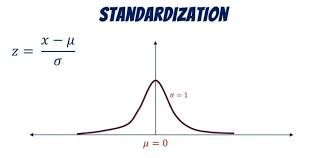


In [13]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mean = X.mean(axis=0)  # mu for each feature
std = np.sqrt(((X - mean) ** 2).sum(axis=0) / X.shape[0])  # sigma for each feature
standardized_data = (X - mean) / std  # z = (x - mu) / sigma
# (Do not use sklearn)

print('Means after standardization :', standardized_data.mean(axis=0).round(6))
print('Std devs after standardization:', standardized_data.std(axis=0).round(6))
standardized_data[:5]  # Display the first few rows of standardized data

Means after standardization : [ 0. -0.  0.  0.  0.  0. -0. -0.  0. -0. -0.  0.  0. -0.]
Std devs after standardization: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


array([[-1.247, -0.887, -1.22 , -1.494, -0.411, -0.593, -1.335, -0.01 , -0.624, -1.398, -0.069, -0.29 ,  1.315,
        -0.474],
       [-1.266,  0.08 , -0.974, -1.348, -0.775, -0.593,  0.103, -0.01 , -0.867, -1.398, -0.069, -0.29 ,  1.315,
        -0.474],
       [-1.065, -1.08 , -0.974, -1.458,  0.497,  0.028, -0.813, -0.176, -0.624, -1.398, -0.069,  3.454, -0.76 ,
        -0.474],
       [-1.065, -0.822, -1.195, -1.348, -0.865, -0.593, -0.813, -0.673, -0.915, -1.398, -0.069,  3.454, -0.76 ,
        -0.474],
       [-1.119, -0.629, -1.466, -1.567,  0.497, -0.096, -1.205, -0.01 , -0.867, -1.398, -0.069, -0.29 ,  1.315,
        -0.474]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [14]:
# Step 3: Calculate the Covariance Matrix
n = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)  # data is already centred

print('Shape:', cov_matrix.shape, '| symmetric:', np.allclose(cov_matrix, cov_matrix.T))
cov_matrix

Shape: (14, 14) | symmetric: True


array([[ 1.001,  0.768,  0.778,  0.717,  0.469,  0.588,  0.688,  0.492,  0.617,  0.665,  0.011, -0.169,  0.006,
         0.128],
       [ 0.768,  1.001,  0.803,  0.581,  0.41 ,  0.462,  0.75 ,  0.514,  0.6  ,  0.687,  0.001, -0.198,  0.141,
         0.073],
       [ 0.778,  0.803,  1.001,  0.724,  0.528,  0.682,  0.725,  0.54 ,  0.768,  0.795,  0.046, -0.222, -0.021,
        -0.002],
       [ 0.717,  0.581,  0.724,  1.001,  0.531,  0.7  ,  0.697,  0.575,  0.655,  0.816,  0.101, -0.272,  0.038,
        -0.003],
       [ 0.469,  0.41 ,  0.528,  0.531,  1.001,  0.546,  0.472,  0.44 ,  0.533,  0.559,  0.082, -0.212, -0.153,
         0.006],
       [ 0.588,  0.462,  0.682,  0.7  ,  0.546,  1.001,  0.525,  0.518,  0.665,  0.686,  0.029, -0.157, -0.101,
        -0.038],
       [ 0.688,  0.75 ,  0.725,  0.697,  0.472,  0.525,  1.001,  0.589,  0.592,  0.782,  0.005, -0.247,  0.165,
         0.089],
       [ 0.492,  0.514,  0.54 ,  0.575,  0.44 ,  0.518,  0.589,  1.001,  0.473,  0.63 ,  0.011, -

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = None  # Perform eigendecomposition
eigenvalues, eigenvectors

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = None  # Sort eigenvalues in descending order
sorted_eigenvectors = None  # Sort eigenvectors accordingly
sorted_eigenvectors

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = None  # Decide on the number of principal components to keep
reduced_data = None  # Project data onto the principal components
reduced_data[:5]

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

In [ ]:
# Step 8: Visualize Before and After PCA


# Plot original data (first two features for simplicity)


# Plot reduced data after PCA


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
